# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos. 
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas. 
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")

## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [2]:
titanic = pd.read_csv("titanic_semana_02.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **cuáles variables son numéricas y cuáles son categóricas?**

Variables categóricas: Name, Sex, Ticket, Cabin, Embarked.

Variables numéricas: Survived, Pclass, Age, SibSp, Parch, Fare


In [3]:
titanic.shape[0], titanic.describe(), titanic.info(), titanic.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


(891,
        PassengerId    Survived      Pclass         Age       SibSp  \
 count   891.000000  891.000000  891.000000  714.000000  891.000000   
 mean    446.000000    0.383838    2.308642   29.699118    0.523008   
 std     257.353842    0.486592    0.836071   14.526497    1.102743   
 min       1.000000    0.000000    1.000000    0.420000    0.000000   
 25%     223.500000    0.000000    2.000000   20.125000    0.000000   
 50%     446.000000    0.000000    3.000000   28.000000    0.000000   
 75%     668.500000    1.000000    3.000000   38.000000    1.000000   
 max     891.000000    1.000000    3.000000   80.000000    8.000000   
 
             Parch        Fare  
 count  891.000000  891.000000  
 mean     0.381594   32.204208  
 std      0.806057   49.693429  
 min      0.000000    0.000000  
 25%      0.000000    7.910400  
 50%      0.000000   14.454200  
 75%      0.000000   31.000000  
 max      6.000000  512.329200  ,
 None,
 Index(['PassengerId', 'Survived', 'Pclass', 'Na

# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
Hay un total de 891 Pasajeros en la base de datos.
- ¿Qué características contiene la base de datos?
Supervivencia, clase de pasajero, sexo, edad, tarifa, cantidad de familiares, puerto de embarque
- ¿Cómo se distribuyen por sexo y clase?

- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


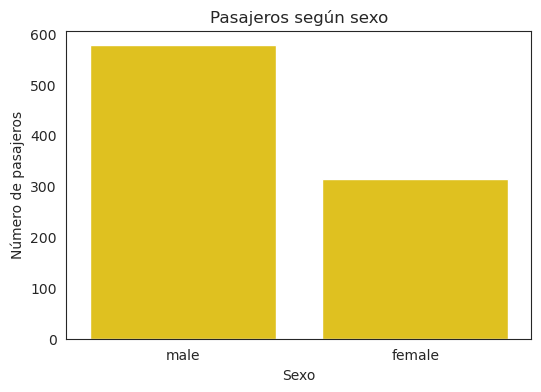

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="gold")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()

### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?

La clase que más pasajeros contiene es la tercera.

- La muestra está balanceada entre las tres clases?

La muestra no está tan balanceada, se nivela entre la primera y segunda clase, pero se dispara en la tercera. 


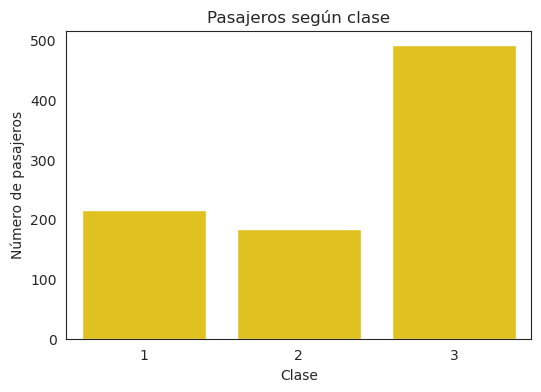

In [5]:
# Escriba aquí su código

plt.figure(figsize=(6,4))
sns.countplot(data=titanic, x="Pclass", color="gold")
plt.xlabel("Clase")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según clase")
plt.show()

**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?

Las edades más frecuentes se concentran aproximadamente entre los 20 y 30 años. La edad media de los pasajeros es cercana a los 30 años.

- ¿La distribución parece simétrica?

No es perfectamente simétrica ya que podemos notar que hay mayor frecuencia para los jóvenes mientras que empieza a disminuir con edades mas avanzadas.  

- ¿El número de bins cambia su interpretación?

Si, al cambiar el número de bins la interpretacion puede ser distinta, por ejemplo en la detección de outliers o incluso identificar la distribución de los datos  

In [6]:
mean_age = titanic["Age"].mean()
print(f"Edad promedio: {mean_age:.2f} años")

Edad promedio: 29.70 años


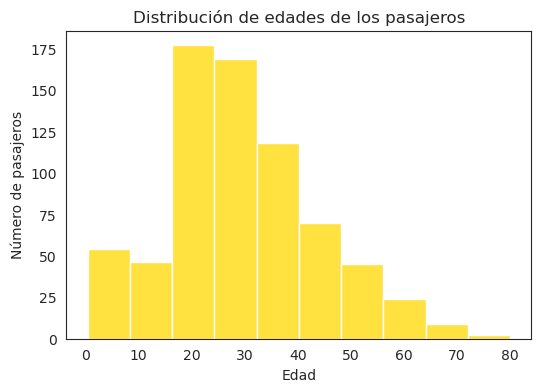

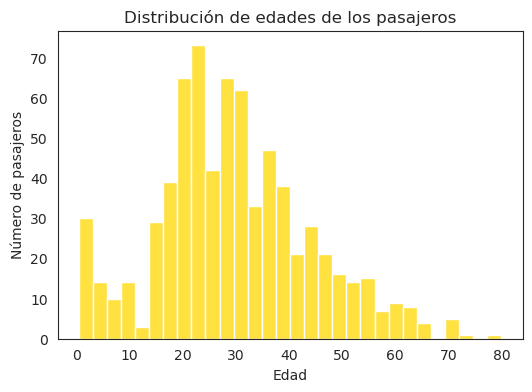

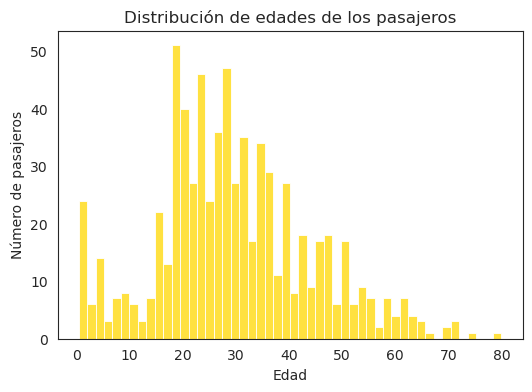

In [7]:
# Escriba aquí su código
# sns.histplot(...)


for i in [10,30,50]:
    plt.figure(figsize=(6,4))
    sns.histplot(data=titanic, x="Age", bins=i, color="gold")
    plt.xlabel("Edad")
    plt.ylabel("Número de pasajeros")
    plt.title("Distribución de edades de los pasajeros")
    plt.show()

**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?

No, claramente se puede ver una tendencia en donde la mayor cantidad de pasajeros pagó las tarifas más bajas

- ¿Existen tarifas muy superiores al resto?

Si, visualizando el histograma podemos ver que hubo gente que pagó tarifas de hasta 500.

- ¿Qué podría significar esto?

Las tarifas más bajas probablemente corresponden a las personas que se encuentran en la tercera clase, mientras que las tarifas más altas corresponden a segunda y primera clase. Otra posibilidad es que tarifas tan altas puedan implicar que no fueron individuales, es decir que se pagó tarifas correspondientes a un grupo de personas.

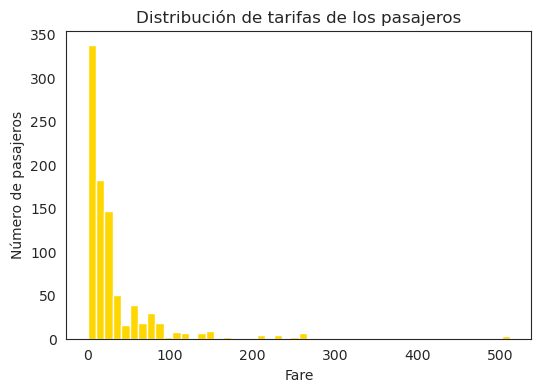

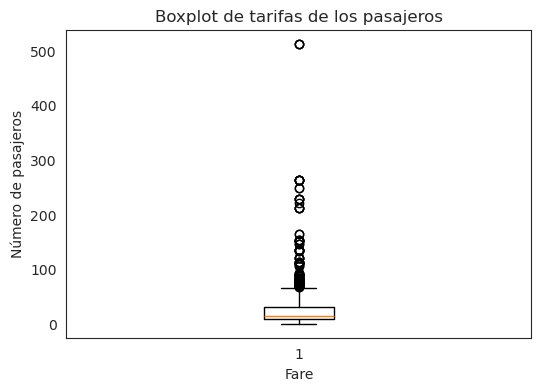

In [8]:
# Escriba aquí su código
plt.figure(figsize=(6,4))
plt.hist(titanic["Fare"], bins=50, color="gold")
plt.xlabel("Fare")
plt.ylabel("Número de pasajeros")
plt.title("Distribución de tarifas de los pasajeros")
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(titanic["Fare"])
plt.xlabel("Fare")
plt.ylabel("Número de pasajeros")
plt.title("Boxplot de tarifas de los pasajeros")
plt.show()

# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [10]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


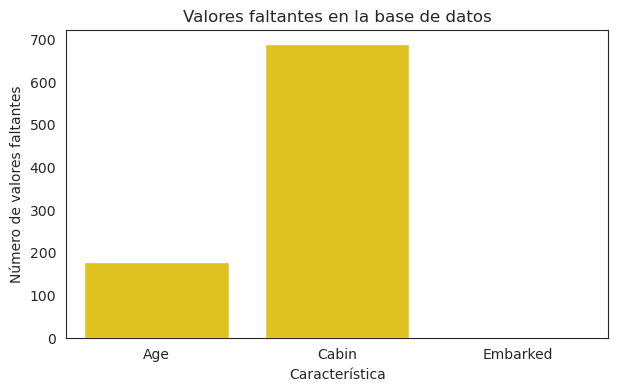

In [11]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))
sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')
plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")
plt.show()

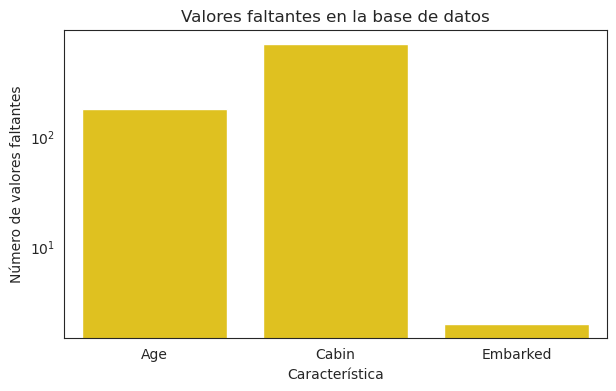

In [12]:
plt.figure(figsize=(7,4))
sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')
plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.yscale("log")
plt.title("Valores faltantes en la base de datos")
plt.show()
# Decidí añadir un yscale log para que haya una mejor visualización de los datos faltantes, ya que son muy pocos los datos faltantes de Embarked

### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?
- Es la media una buena representación de una edad típica?

La media de edad es de 29,7 años, mientras que la mediana es de 28 años. Ambas son similares, por lo que la media es una representación razonable de una edad típica para este conjunto de datos. Sin embargo, en presencia de valores extremos (outliers), la mediana puede resultar más representativa, ya que es menos sensible a estos valores que la media.


In [13]:
# Escriba aquí su código

print("Media de la edad:", np.mean(titanic["Age"]))
print("Mediana de la edad:", np.median(titanic["Age"].dropna()))

#no tenemos problemas al calcular la media pero para la mediana tenemos que eliminar los valores nulos, por eso usamos .dropna()

Media de la edad: 29.69911764705882
Mediana de la edad: 28.0


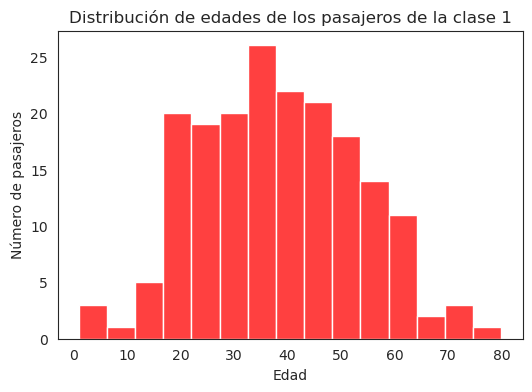

Clase 1: Media de edad = 38.23, Mediana de edad = 37.00


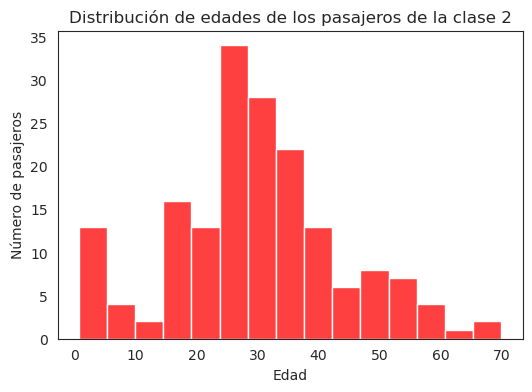

Clase 2: Media de edad = 29.88, Mediana de edad = 29.00


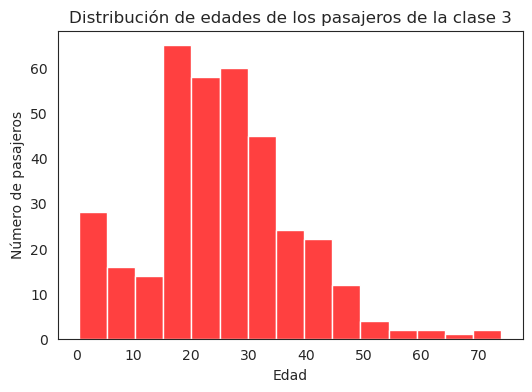

Clase 3: Media de edad = 25.14, Mediana de edad = 24.00


In [14]:
#distribucion de edades segun clase

for i in [1,2,3]:
    plt.figure(figsize=(6,4))
    datos_clase = titanic[(titanic["Age"].notnull()) & (titanic["Pclass"] == i)
    ]
    sns.histplot(data=datos_clase, x="Age", bins=15, color="red")
    plt.xlabel("Edad")
    plt.ylabel("Número de pasajeros")   
    plt.title(f"Distribución de edades de los pasajeros de la clase {i}")
    plt.show()
    print(f"Clase {i}: Media de edad = {datos_clase['Age'].mean():.2f}, Mediana de edad = {datos_clase['Age'].median():.2f}")


**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media?
- Qué problema podría producir esa decisión en la distribución de edades?
- Qué otra estrategia consideraría?

Reemplazar todas las edades faltantes por la media de 29 años no lo considero una buena opción, ya que esto haría que muchos datos tuvieran el mismo valor y afectaría la distribución de las edades. Una posible solución sería asignar las edades de manera aleatoria basándose en la distribución que ya tenemos, lo que permitiría obtener valores más acordes con la distribución observada y mantener una mayor variabilidad en los datos.

**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos?
- Eliminaría la característica?
- Podría el hecho de conocer o no la cabina contener información por sí mismo?

No completaria los valores faltantes de Cabin, ya que existe una gran cantidad de datos faltantes, por lo que intentar reconstruir esta información sería bastante complicado. Incluso si utilizarmos la variable Pclass para intentar asignar aleatoriamente posibles cabinas (si es que conocieramos los planos del Titanic). Considero que Pclass por sí misma es una característica más útil, ya que entra casi la misma información que entregaría Cabin de manera indirecta.  


**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso?
- Por qué el tratamiento puede ser distinto al de `Cabin`?

En este caso utilizaría una estrategia simple como reemplazar los valores faltantes por la moda, es decir, por el puerto de embarque más frecuente. Esto es razonable. por lo que el impacto sobre la distribución sería mínimo. En cambio, en Cabin utilizar la moda no sería una buena opción, ya que existe una gran cantidad de valores faltantes y reemplazarlos todos por el valor más frecuente afectaria significativamente la distribución original.

# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?




### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


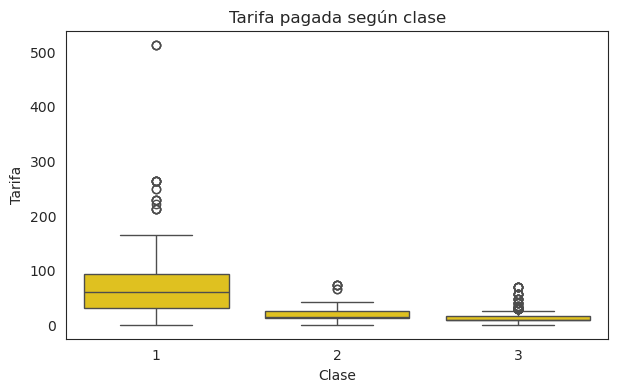

In [15]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase?
- Hay dispersión dentro de cada clase?
- Existen valores extremos?
- Diría que `Fare` y `Pclass` contienen exactamente la misma información?

La tarifa al parecer puede estar relacionada con la clase debido a que en el caso de primera clase se pueden apreciar tarifas mayores en comparacion con las otras clases y que incluso esta relacion disminuye para tarifas bajas, es decir, si es menor la clase, menor será la tarifa. dentro de cada clase también existe la dispersión de los datos, por ejemplo, en la primera clase se ve que existe un rango amplio de valores mientras que las otras clases el rango es mas pequeño. Se pueden identificar valores extremos o tambien llamados outliers  en donde muchas existen tarifas superiores a 200 e incluso de 500. Fare y Pclass no contiene la misma informacion pero estan relacionadas, como ya se discutió Pclass es una variable categorica y Fare es una variable continua.  





### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?
- Qué diferencias observa?

Las edades no son similares para todas las clases, vemos una tendencia donde la edad disminuye a media de que la clase es más baja (segunda o tercera clase). La primera clase muestra mayor dispersión mientras que la segunda y tercera clase aparecen varios outliers con edades mayores.

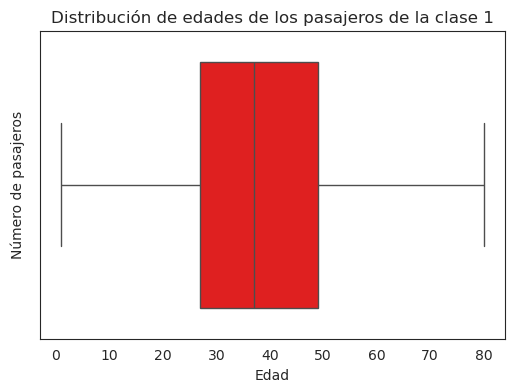

Clase 1: Media de edad = 38.23, Mediana de edad = 37.00


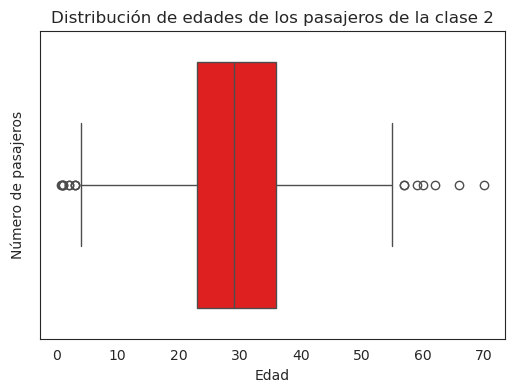

Clase 2: Media de edad = 29.88, Mediana de edad = 29.00


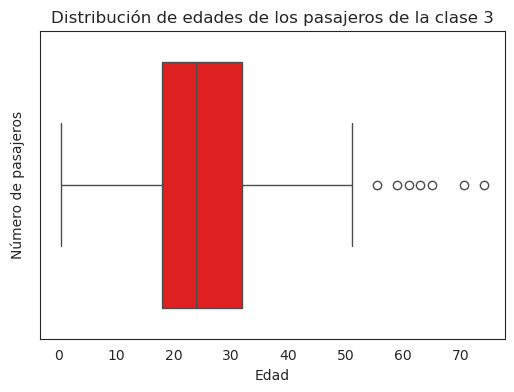

Clase 3: Media de edad = 25.14, Mediana de edad = 24.00


In [16]:
# Escriba aquí su código
# sns.boxplot(...)

for i in [1,2,3]:
    plt.figure(figsize=(6,4))
    datos_clase = titanic[(titanic["Age"].notnull()) & (titanic["Pclass"] == i)]
    sns.boxplot(data=datos_clase, x="Age", color="red")
    plt.xlabel("Edad")
    plt.ylabel("Número de pasajeros")   
    plt.title(f"Distribución de edades de los pasajeros de la clase {i}")
    plt.show()
    print(f"Clase {i}: Media de edad = {datos_clase['Age'].mean():.2f}, Mediana de edad = {datos_clase['Age'].median():.2f}")


**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [17]:
# Complete el código

titanic["Familia"] = titanic["SibSp"] + titanic["Parch"] + 1

print(titanic["Familia"].value_counts().sort_index())
print("\nProporción viajando solos:", (titanic["Familia"] == 1).mean())
print("\nSibSp:\n", titanic["SibSp"].describe())
print("\nParch:\n", titanic["Parch"].describe())

Familia
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

Proporción viajando solos: 0.6026936026936027

SibSp:
 count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64

Parch:
 count    891.000000
mean       0.381594
std        0.806057
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000
Name: Parch, dtype: float64


**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?
- Hay grupos familiares muy grandes?
- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?

La mayoría de los pasajeros viajaba sola, el valor más frecuente es de 1 que corresponde a la pasajero mismo. Si existen grupos familiares grandes, aunque son pocos, familias de 8 y de 11. Respecto a SibSp o Parch por separado, ya que da una visión incompleta, cada una cuenta solo un tipo de familiar. Familia las suma a ambas y agrega al pasajero.

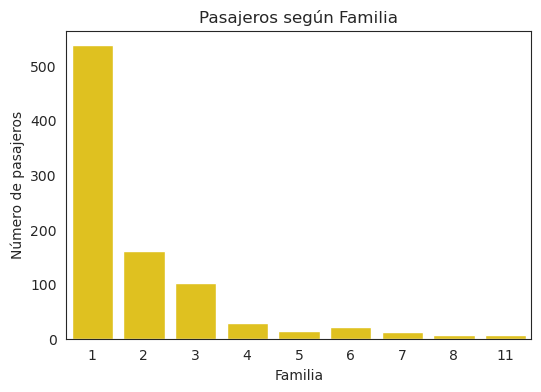

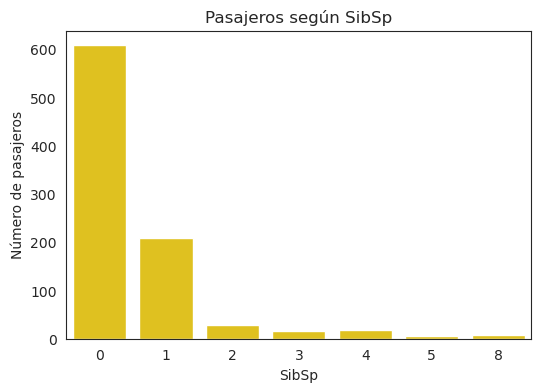

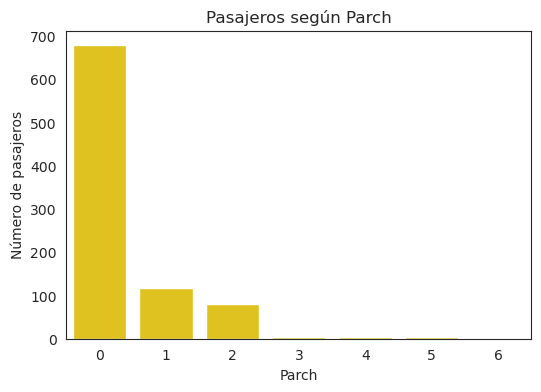

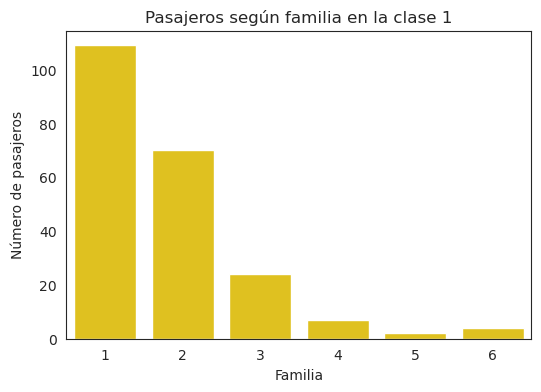

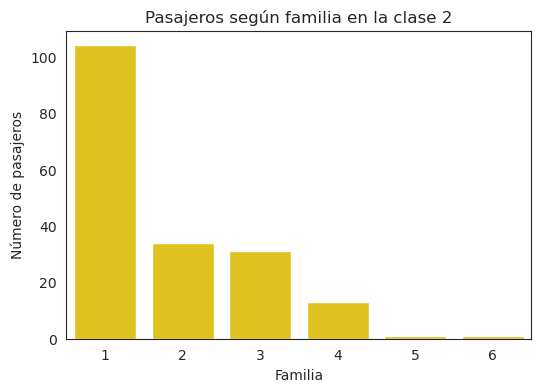

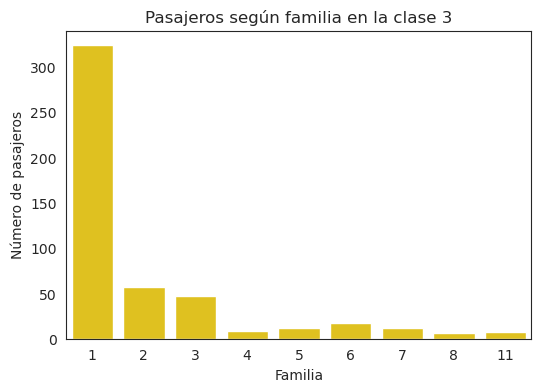

In [18]:
# Escriba aquí su código

familiar = ["Familia", "SibSp", "Parch"]
clase = [1,2,3]
familia_clase = titanic[(titanic["Familia"]) & (titanic["Pclass"].isin(clase))]

for i in familiar:
    plt.figure(figsize=(6,4))
    sns.countplot(data=titanic, x=titanic[i], color="gold")
    plt.xlabel(i)
    plt.ylabel("Número de pasajeros")
    plt.title(f"Pasajeros según {i}")
    plt.show()

for i in clase:
    plt.figure(figsize=(6,4))
    sns.countplot(data=titanic[titanic["Pclass"] == i], x="Familia", color="gold")
    plt.xlabel("Familia")
    plt.ylabel("Número de pasajeros")
    plt.title(f"Pasajeros según familia en la clase {i}")
    plt.show()


# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


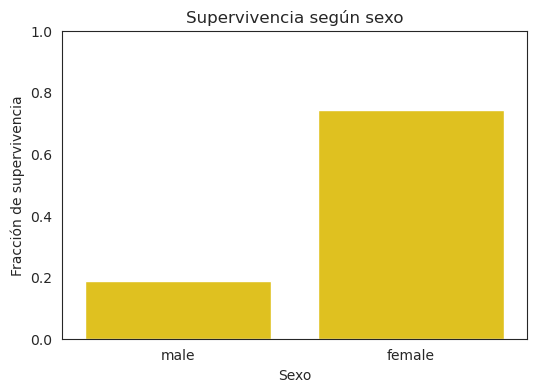

In [19]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()

### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres?
- Podemos concluir a partir de este gráfico por qué existe la diferencia?

La fracción de supervivencia no es similar entre hombres y mujeres, ya que en el caso de las mujeres su tasa de supervivencia fue mucho mayor que la de los hombres, ya que correlación no implica causalidad no se puede concluir pero se adecúa al dicho "mujeres y niños primero". 

### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?
- Existe una tendencia?

Se ve que existen diferencias entre las tres clases y se observa una clara tendencia en donde empieza a descender, a medida que disminuye el nivel socioeconomico de la clase, la tasa de supervivencia disminuye. Primera clase con mas del 60%, mientras que la más baja, la tercera clase con 24%.

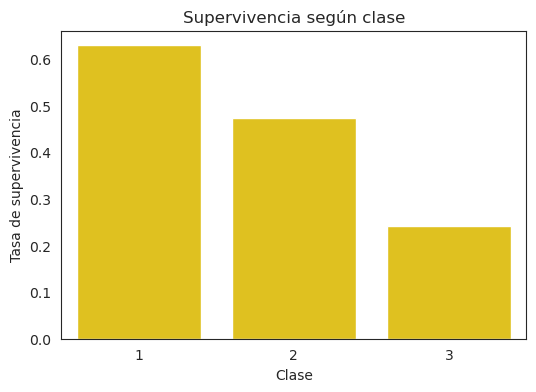

In [20]:
# Escriba aquí su código

plt.figure(figsize=(6,4))
sns.barplot(data=titanic, x="Pclass",y="Survived", errorbar=None, color="gold")
plt.xlabel("Clase")
plt.ylabel("Tasa de supervivencia")
plt.title("Supervivencia según clase")
plt.show()

**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?
- Hay algún grupo de edad que llame particularmente su atención?

Sí, los pasajeros más jóvenes fueron los que tuvieron una mayor tasa de supervivencia, en comparación con el resto de pasajeros de otras edades. El grupo de edad mayores de 75 años tiene un 100% de tasa de supervivencia lo cual puede llamar bastante la atención, pero revisando la cantidad de pasajeros que se encontraba dentro de ese grupo fue de 1 persona, por tanto la muestra al ser tan pequeña puede no significar mucho.

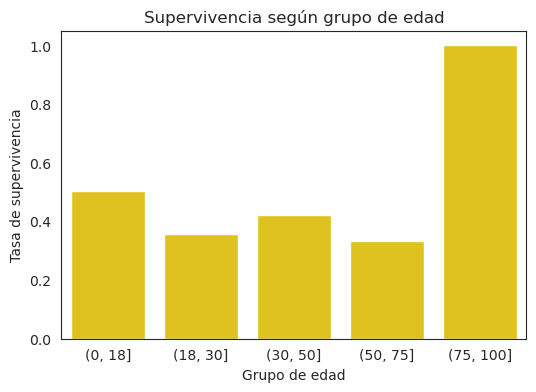

Age_group
(0, 18]      139
(18, 30]     270
(30, 50]     241
(50, 75]      63
(75, 100]      1
Name: count, dtype: int64

In [21]:
# Escriba aquí su código

group_ages = [0,18,30,50,75,100]
titanic["Age_group"] = pd.cut(titanic["Age"], bins=group_ages)
plt.figure(figsize=(6,4))
sns.barplot(data=titanic, x="Age_group", y="Survived", errorbar=None, color="gold")
plt.xlabel("Grupo de edad")
plt.ylabel("Tasa de supervivencia")
plt.title("Supervivencia según grupo de edad")
plt.show()

titanic["Age_group"].value_counts().sort_index()


**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?
- La relación parece simple?
- Qué ocurre con los grupos familiares grandes?

En el gráfico se observa que viajar solo tiene una tasa baja, cercana al 30%, comparando con otros pasajeros de con mas familiares puede considerarse desfavorable. No parece una relacion simple ya que la tasa de supervivencia parte baja con 1 pasajero y aumenta al llegar hasta 4 familiarles para luego descender drasticamente a familias de 5 o más. Los grupos familiares grandes tuvieron tasas de supervivencia extremadamente bajas.


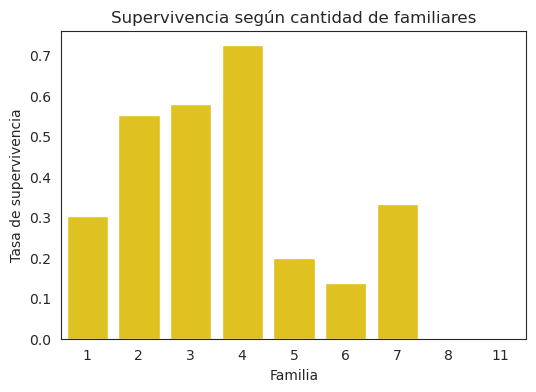

Familia
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [22]:
# Escriba aquí su código

plt.figure(figsize=(6,4))
sns.barplot(data=titanic, x="Familia", y="Survived", errorbar=None, color="gold")
plt.xlabel("Familia")
plt.ylabel("Tasa de supervivencia")
plt.title("Supervivencia según cantidad de familiares")
plt.show()

titanic["Familia"].value_counts().sort_index()

# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


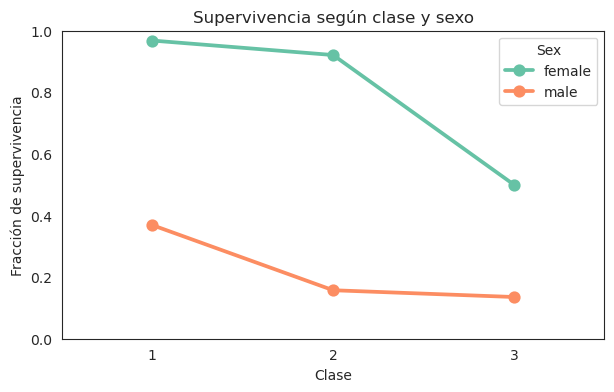

In [22]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres?
- Qué información se perdía cuando mirábamos solamente `Pclass`?
- Qué información se perdía cuando mirábamos solamente `Sex`?
- Hay algún grupo particularmente favorecido o desfavorecido?

La relacion entre clase y supervivencia no es igual, para las mujeres la supervivencia baja moderadamente entre clases, pero sigue siendo alta, mientras que para los hombres la tasa de supervivencia es baja en todas las clases. Sí mirábamos solamente Pclass se perdía la diferencia vista por sexo para cada clase. Si mirábamos solamente Sex se pierde informacion sobre como la clase termina alterando la supervivencia para cada sexo. El grupo más favorecido fue mujeres de primera y segunda clase mientras que el más desfavorecido fue hombres de segunda y tercera clase.

### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [65]:
def clasificacion(fila):
    if pd.notna(fila["Age"]) and fila["Age"] < 16:
        return "niño/a"
    elif fila["Sex"] == "female":
        return "mujer"
    else:
        return "hombre"

titanic["Persona"] = titanic.apply(clasificacion, axis=1)
titanic["Persona"].value_counts()

Persona
hombre    537
mujer     271
niño/a     83
Name: count, dtype: int64

**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?
- La clase sigue siendo importante dentro de cada grupo?
- Qué combinación de características parece asociarse con la mayor supervivencia?


Los niños no presentan el mismo patrón que los adultos, se ve que para la primera clase los niños tienen una supervivencia menor que las mujeres pero que en segunda clase esto se invierte donde los niños tienen una alta tasa de supervivencia, para luego en la tercera clase llegar de nuevo a que la tasa de supervivencia de niños es menor que el de las mujeres. Si la clase sigue siendo importante ya que en el caso de los hombres cae abruptamente de primera a segunda clase para luego estabilizarse, para las mujeres cae de manera moderada y niños/as de primera clase tienen baja pero de segunda sube a una tasa de supervivencia casi de 100% para luego en tercera clase caer casi al 40%. La combinacion más favorable para obtener una mayor tasa de supervivencia sería la de un niño/a o también una mujer que pertenezcan a la primera o segunda clase. 


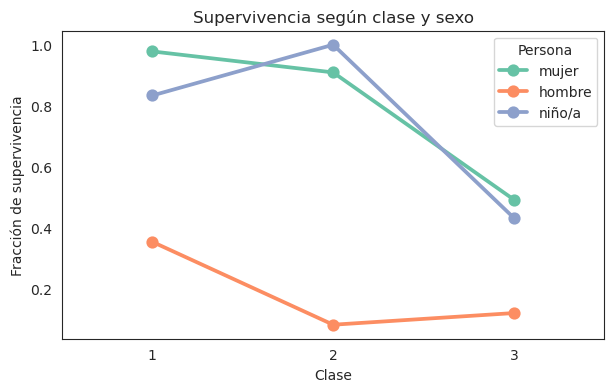

In [48]:
# Escriba aquí su código

plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Persona",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")

plt.show()

**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


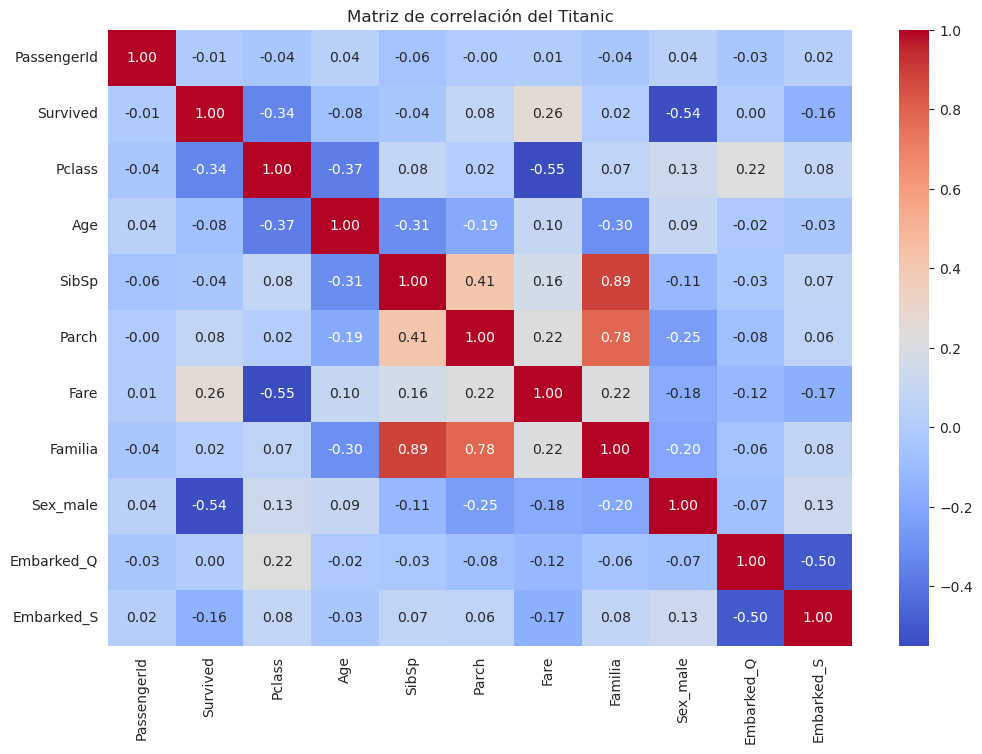

In [30]:
titanic_encoded = pd.get_dummies(
    titanic,
    columns=["Sex", "Embarked"],
    drop_first=True
)

corr_matrix = titanic_encoded.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación del Titanic")
plt.show()

#Hago una matriz de correlación para ver que parámetros pueden importar bastante si es que quiero incorporar una tercera característica

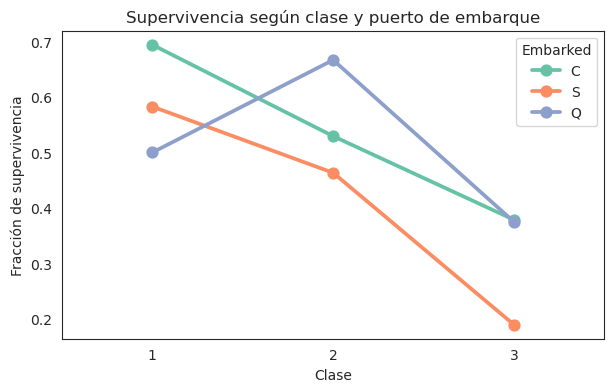

Embarked  Pclass
C         1          85
          2          17
          3          66
Q         1           2
          2           3
          3          72
S         1         127
          2         164
          3         353
dtype: int64

In [29]:
# Pregunta:¿La supervivencia según la clase sigue el mismo patrón en los tres puertos de embarque, o el efecto de la clase depende de dónde embarcó la persona?

# Código:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Embarked",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y puerto de embarque")

plt.show()
titanic.groupby(["Embarked","Pclass"]).size()

**¿La supervivencia según la clase sigue el mismo patrón en los tres puertos de embarque?**

El patron no es el mismo en los tres puertos. En C y S la supervivencia disminuye a medida que empeora la clase, aunque lo hace de distinta forma S de segunda a tercera clase cae de manera más rapida. Por otra parte Q no sigue esta tendencia, la supervivencia sube de primera a segunda clase, luego cae al pasar a tercera clase. 


# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**
- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**


No podemos concluir que solo a partir de esta base de datos se dió prioridad a mujeres y niños los datos muestran correlación, pero recordemos que correlación no implica causalidad, el dato no nos dice por qué ocurrio esa diferencia, puede la hipotesis ser consistente pero no la confirma. Se necesitaría para evaluar la hipotesis de, por ejemplo, tener la hora y quienes subieron primero a cada bote al momento del hundimiento, posicion de las cabinas por clase respecto a los botes. Toda esta posible información adicional permitiría determinar si la prioridad fue niños y mujeres o si en realidad hubieron otros parámetros implicados nuevamente como la clase. Otras explicaciones podrían producir un patrón similar podría ser la ubicaciones de las cabinas de mujeres y niños, es posible que hayan estado cerca de los botes de evacuacion. 

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo
- clase
- edad
- tamaño de familia.

Esta muestra del titanic contenia 891 pasajeros los cuales su mayoria se ubicaba en la tercera clase, mientras que la primera y segunda clase era más homogenea en cuanto a cantidad de pasajeros. La edad promedio de los pasajeros era de 29 años. Respecto a la familia, la mayoría de los pasajeros viajaban solos aunque habían familias grandes que eran poco frecuentes.


### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo
- clase
- edad
- viajar solo o acompañado.


Las mujeres tuvieron una fracción de supervivencia mucho mayor que los hombres, la supervivencia disminuyó de forma clara a medida que la clase bajaba, la supervivencia de los pasajeros jóvenes fue mayor que la de los adultos, y viajar solo generó una supervivencia muy baja al igual que las familias más grandes, por otra parte familias intermedias (2-4 personas) la tasa de supervivencia fue relativamente buena.


### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

Use como ejemplo al menos uno de los análisis multivariados realizados.

El análisis que se hizo de Clase + Sexo + Supervivencia fue clave para distinguir entre hombres y mujeres. Las mujeres si las comparamos con los hombres fueron las que su tasa de supervivencia fue más alta, en cambio los hombres en las tres clases su fraccion de supervivencia fue extremadamente baja. Es decir, la relación entre clase y supervivencia dependía fuertemente del sexo, algo que no se podía ver mirando cada variable por separado.

### 4. Encontró características que contienen información relacionada?

Explique al menos un caso.

Si nos fijamos en la matriz de correlación podemos establecer muchas caracteristicas en los parámetros de el set de datos. La tarifa y la clase estaban fuertemente relacionadas (-0.55), Familia con SibSp y Parch ya que se construyo a partir de estos(0.89 y 0.78).


### 5. Qué resultado le pareció más inesperado?

Proponga una posible explicación, dejando claro qué parte corresponde a una observación y qué parte corresponde a una hipótesis.

El resultado que me pareció inesperado fue observar que la supervivencia en Q  subió al pasar de primera a segunda clase en vez de bajar como pasó con C y S, es decir, no siguió la misma tendencia.  Como observacion se puede notar que son pocos los pasajeros de Q, sobre todo en la primera y segunda clase. Como Hipótesis propongo que es posible que los pasajeros provenientes de Q pertenecieran mayormente a un grupo socioeconómico bajo, muy distinto al de quienes embarcaron en C o S, por tanto los pocos pasajeros de primera clase desde ese puerto no fueran realmente comparables en términos socioeconómicos con los de primera clase de los otros puertos.


# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió...**

*(Complete con un párrafo breve basado en su análisis.)*

Correspondía a una mujer posiblemente de primera o segunda clase, viajando en un grupo familiar de entre 2 a 4 personas. Su probabilidad de supervivencia fue alta independientemente de su edad, incluso si era menor de 18 años. El sexo fue la variable que más se vió afectada en los datos, que junto con la clase social fue más determinante. Los hombres tuvieron baja supervivencia en casi todas las clases. El grupo familiar también influyó, al igual que viajar solo o en grupos familiares muy grandes. En conjunto, el perfil más favorecido fue el de una mujer o niño/a de clase alta con un grupo familiar pequeño, lo que sugiere que el patrón de mujeres y niños primero estuvo combinado con un fuerte factor socioeconómico.